# Machine Learning Model Performance Comparison for Student Performance Prediction

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

project_path = "/content/drive/My Drive/SP452_Natthamon_Final_Project"
os.chdir(project_path)

print("Current folder:", os.getcwd())
print("Files:", os.listdir())

Current folder: /content/drive/My Drive/SP452_Natthamon_Final_Project
Files: ['Student_performance_data_.csv']


# Load Dataset

In [ ]:
df = pd.read_csv("Student_performance_data_.csv")

df.head()

,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
0,1001,17,1,0,2,19.833723,7,1,2,0,0,1,0,2.929196,2.0
1,1002,18,0,0,1,15.408756,0,0,1,0,0,0,0,3.042915,1.0
2,1003,15,0,2,3,4.210570,26,0,2,0,0,0,0,0.112602,4.0
3,1004,17,1,0,3,10.028829,14,0,3,1,0,0,0,2.054218,3.0
4,1005,17,1,0,2,4.672495,17,1,3,0,0,0,0,1.288061,4.0


# Data Understanding and Data Cleaning

In [ ]:
print("จำนวนแถวและคอลัมน์:", df.shape)

print("\nชื่อคอลัมน์ทั้งหมด:")
print(df.columns)

จำนวนแถวและคอลัมน์: (2392, 15)

ชื่อคอลัมน์ทั้งหมด:
Index(['StudentID', 'Age', 'Gender', 'Ethnicity', 'ParentalEducation',
       'StudyTimeWeekly', 'Absences', 'Tutoring', 'ParentalSupport',
       'Extracurricular', 'Sports', 'Music', 'Volunteering', 'GPA',
       'GradeClass'],
      dtype='object')


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2392 entries, 0 to 2391
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   StudentID          2392 non-null   int64  
 1   Age                2392 non-null   int64  
 2   Gender             2392 non-null   int64  
 3   Ethnicity          2392 non-null   int64  
 4   ParentalEducation  2392 non-null   int64  
 5   StudyTimeWeekly    2392 non-null   float64
 6   Absences           2392 non-null   int64  
 7   Tutoring           2392 non-null   int64  
 8   ParentalSupport    2392 non-null   int64  
 9   Extracurricular    2392 non-null   int64  
 10  Sports             2392 non-null   int64  
 11  Music              2392 non-null   int64  
 12  Volunteering       2392 non-null   int64  
 13  GPA                2392 non-null   float64
 14  GradeClass         2392 non-null   float64
dtypes: float64(3), int64(12)
memory usage: 280.4 KB


In [ ]:
df.isnull().sum()

,0
StudentID,0
Age,0
Gender,0
Ethnicity,0
ParentalEducation,0
StudyTimeWeekly,0
Absences,0
Tutoring,0
ParentalSupport,0
Extracurricular,0


In [ ]:
df.describe()

,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
count,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000
mean,2196.500000,16.468645,0.510870,0.877508,1.746237,9.771992,14.541388,0.301421,2.122074,0.383361,0.303512,0.196906,0.157191,1.906186,2.983696
std,690.655244,1.123798,0.499986,1.028476,1.000411,5.652774,8.467417,0.458971,1.122813,0.486307,0.459870,0.397744,0.364057,0.915156,1.233908
min,1001.000000,15.000000,0.000000,0.000000,0.000000,0.001057,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1598.750000,15.000000,0.000000,0.000000,1.000000,5.043079,7.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.174803,2.000000
50%,2196.500000,16.000000,1.000000,0.000000,2.000000,9.705363,15.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,1.893393,4.000000
75%,2794.250000,17.000000,1.000000,2.000000,2.000000,14.408410,22.000000,1.000000,3.000000,1.000000,1.000000,0.000000,0.000000,2.622216,4.000000
max,3392.000000,18.000000,1.000000,3.000000,4.000000,19.978094,29.000000,1.000000,4.000000,1.000000,1.000000,1.000000,1.000000,4.000000,4.000000


# Exploratory Data Analysis (EDA)

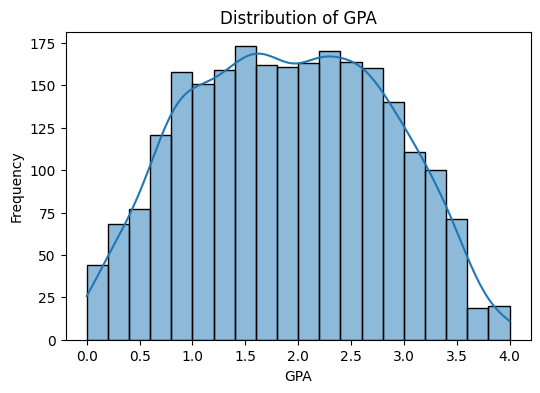

In [ ]:
plt.figure(figsize=(6,4))
sns.histplot(df['GPA'], bins=20, kde=True)
plt.title("Distribution of GPA")
plt.xlabel("GPA")
plt.ylabel("Frequency")
plt.show()

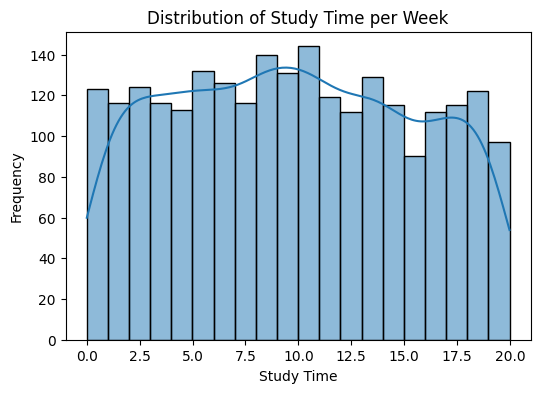

In [ ]:
plt.figure(figsize=(6,4))
sns.histplot(df['StudyTimeWeekly'], bins=20, kde=True)
plt.title("Distribution of Study Time per Week")
plt.xlabel("Study Time")
plt.ylabel("Frequency")
plt.show()

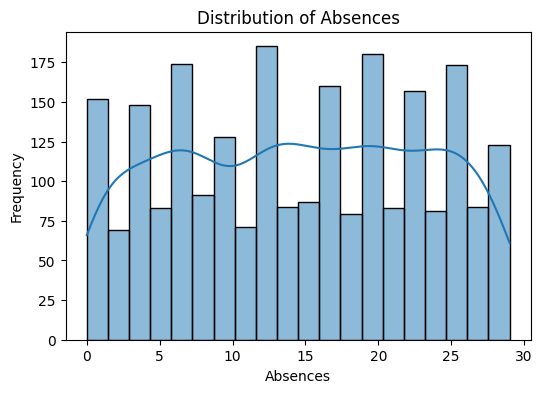

In [ ]:
plt.figure(figsize=(6,4))
sns.histplot(df['Absences'], bins=20, kde=True)
plt.title("Distribution of Absences")
plt.xlabel("Absences")
plt.ylabel("Frequency")
plt.show()

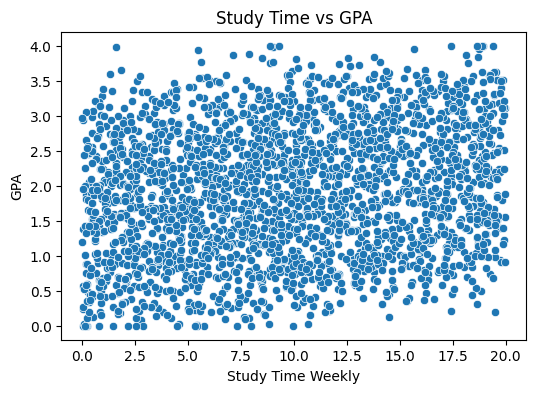

In [ ]:
plt.figure(figsize=(6,4))
sns.scatterplot(x=df['StudyTimeWeekly'], y=df['GPA'])
plt.title("Study Time vs GPA")
plt.xlabel("Study Time Weekly")
plt.ylabel("GPA")
plt.show()

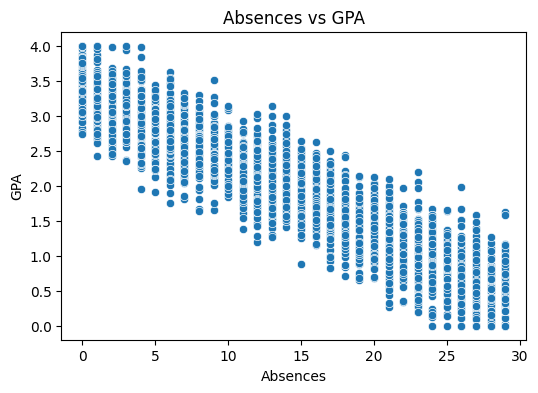

In [ ]:
plt.figure(figsize=(6,4))
sns.scatterplot(x=df['Absences'], y=df['GPA'])
plt.title("Absences vs GPA")
plt.xlabel("Absences")
plt.ylabel("GPA")
plt.show()

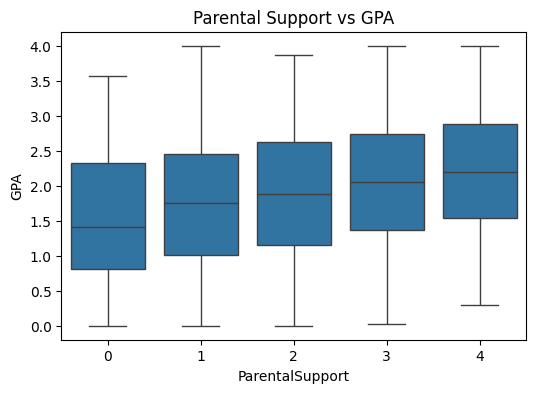

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['ParentalSupport'], y=df['GPA'])
plt.title("Parental Support vs GPA")
plt.show()

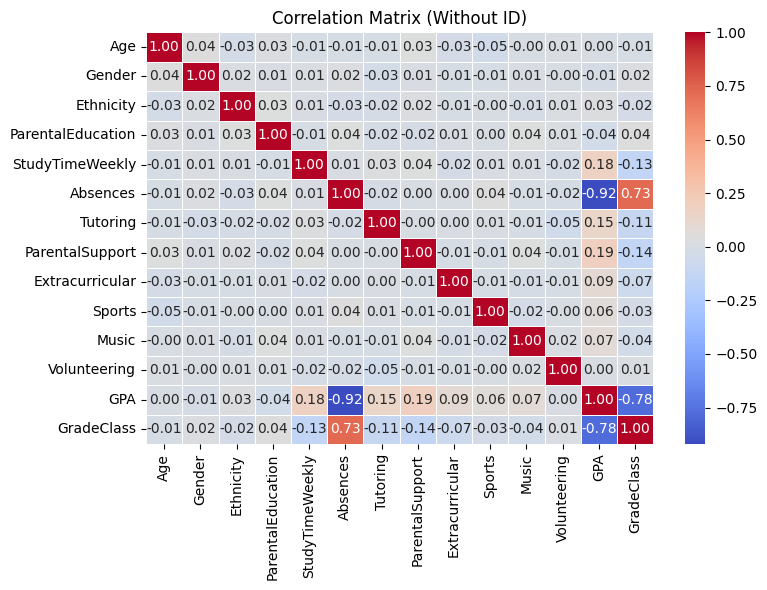

In [ ]:
plt.figure(figsize=(8,6))

corr = df.drop(columns=['StudentID']).corr(numeric_only=True)

sns.heatmap(corr,
            annot=True,
            cmap='coolwarm',
            fmt=".2f",
            linewidths=0.5)

plt.title("Correlation Matrix (Without ID)")
plt.tight_layout()
plt.show()

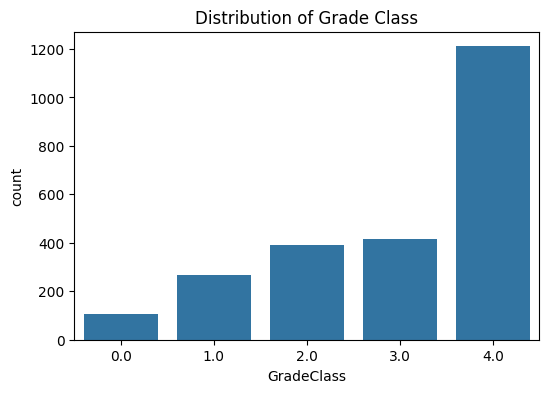

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x=df['GradeClass'])
plt.title("Distribution of Grade Class")
plt.show()

# Feature Selection and Target Variable

In [ ]:
# กำหนดตัวแปรเป้าหมาย (Target)
target = 'GradeClass'

# แยก Features (X) และ Target (y)
X = df.drop(columns=[target, 'StudentID'])
y = df[target]

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (2392, 13)
Shape of y: (2392,)


# Train-Test Split

In [ ]:
from sklearn.model_selection import train_test_split

# แบ่งข้อมูล train และ test
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Train target distribution:\n", y_train.value_counts(normalize=True))
print("Test target distribution:\n", y_test.value_counts(normalize=True))

Train shape: (1913, 13)
Test shape: (479, 13)
Train target distribution:
 GradeClass
4.0    0.506012
3.0    0.173027
2.0    0.163617
1.0    0.112389
0.0    0.044956
Name: proportion, dtype: float64
Test target distribution:
 GradeClass
4.0    0.507307
3.0    0.173278
2.0    0.162839
1.0    0.112735
0.0    0.043841
Name: proportion, dtype: float64


# Logistic Regression Model


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# สร้าง pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=2000, random_state=42))
])

# train
pipeline.fit(X_train, y_train)

# predict
y_pred = pipeline.predict(X_test)

# evaluate
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8016701461377871

Classification Report:
               precision    recall  f1-score   support

         0.0       0.40      0.19      0.26        21
         1.0       0.63      0.54      0.58        54
         2.0       0.64      0.78      0.70        78
         3.0       0.79      0.65      0.72        83
         4.0       0.91      0.97      0.94       243

    accuracy                           0.80       479
   macro avg       0.67      0.63      0.64       479
weighted avg       0.79      0.80      0.79       479



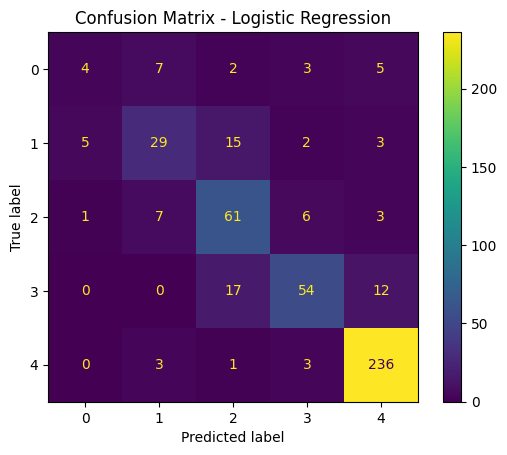

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# สร้าง confusion matrix
cm = confusion_matrix(y_test, y_pred)

# แสดงผลเป็นกราฟ
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Confusion Matrix - Logistic Regression")
plt.show()

# Decision Tree Model


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

# สร้างโมเดล
dt_model = DecisionTreeClassifier(random_state=42)

# train
dt_model.fit(X_train, y_train)

# predict
y_pred_dt = dt_model.predict(X_test)

# evaluate
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("\nClassification Report:\n", classification_report(y_test, y_pred_dt))

Accuracy: 0.8684759916492694

Classification Report:
               precision    recall  f1-score   support

         0.0       0.67      0.38      0.48        21
         1.0       0.72      0.87      0.79        54
         2.0       0.87      0.94      0.90        78
         3.0       0.87      0.78      0.82        83
         4.0       0.92      0.92      0.92       243

    accuracy                           0.87       479
   macro avg       0.81      0.78      0.78       479
weighted avg       0.87      0.87      0.87       479



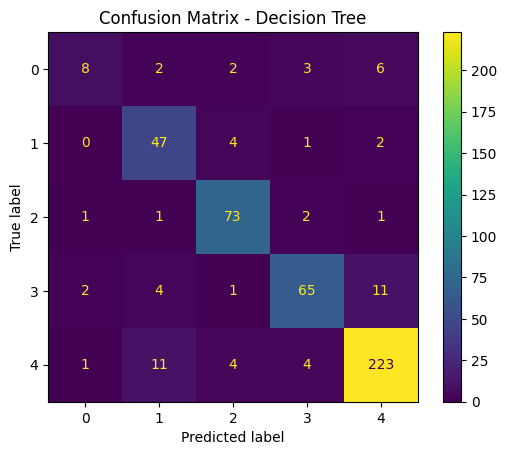

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# สร้าง confusion matrix
cm_dt = confusion_matrix(y_test, y_pred_dt)

# แสดงผลเป็นกราฟ
disp = ConfusionMatrixDisplay(confusion_matrix=cm_dt)
disp.plot()

plt.title("Confusion Matrix - Decision Tree")
plt.show()

# Random Forest Model

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# สร้างโมเดล
rf_model = RandomForestClassifier(random_state=42)

# train
rf_model.fit(X_train, y_train)

# predict
y_pred_rf = rf_model.predict(X_test)

# evaluate
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

Accuracy: 0.9123173277661796

Classification Report:
               precision    recall  f1-score   support

         0.0       1.00      0.29      0.44        21
         1.0       0.82      0.87      0.85        54
         2.0       0.90      0.95      0.93        78
         3.0       0.89      0.89      0.89        83
         4.0       0.94      0.97      0.96       243

    accuracy                           0.91       479
   macro avg       0.91      0.79      0.81       479
weighted avg       0.92      0.91      0.90       479



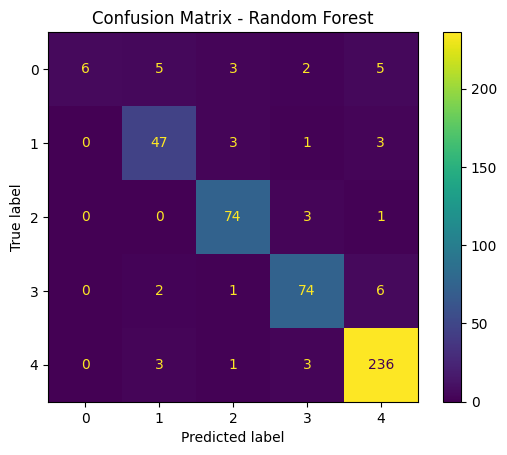

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# confusion matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp.plot()

plt.title("Confusion Matrix - Random Forest")
plt.show()

# Support Vector Machine (SVM) Model

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

svm_model = Pipeline([
    ('scaler', StandardScaler()),
    ('model', SVC())
])

svm_model.fit(X_train, y_train)

y_pred_svm = svm_model.predict(X_test)

print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print("\nClassification Report:\n", classification_report(y_test, y_pred_svm))

SVM Accuracy: 0.7954070981210856

Classification Report:
               precision    recall  f1-score   support

         0.0       0.80      0.19      0.31        21
         1.0       0.65      0.63      0.64        54
         2.0       0.64      0.72      0.68        78
         3.0       0.67      0.71      0.69        83
         4.0       0.92      0.94      0.93       243

    accuracy                           0.80       479
   macro avg       0.74      0.64      0.65       479
weighted avg       0.80      0.80      0.79       479



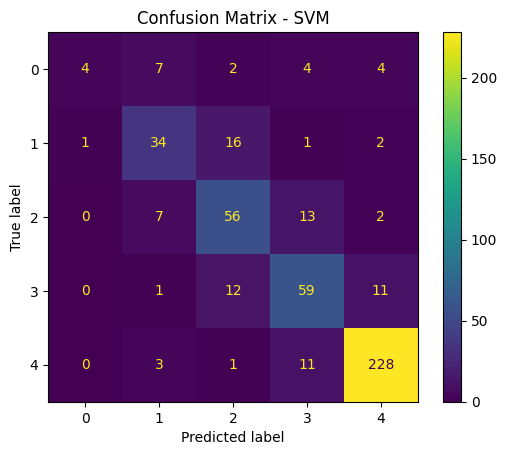

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm_svm = confusion_matrix(y_test, y_pred_svm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_svm)
disp.plot()

plt.title("Confusion Matrix - SVM")
plt.show()

# Model Comparison

In [ ]:
import pandas as pd

results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest', 'SVM'],
    'Accuracy': [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_svm)
    ]
})

print(results)

                 Model  Accuracy
0  Logistic Regression  0.801670
1        Decision Tree  0.868476
2        Random Forest  0.912317
3                  SVM  0.795407


# Model Comparison Visualization

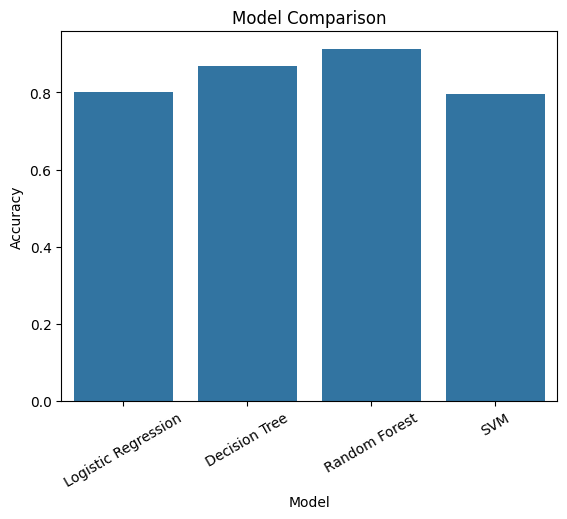

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(x='Model', y='Accuracy', data=results)
plt.title("Model Comparison")
plt.xticks(rotation=30)
plt.show()

# Confusion Matrix of Best Model

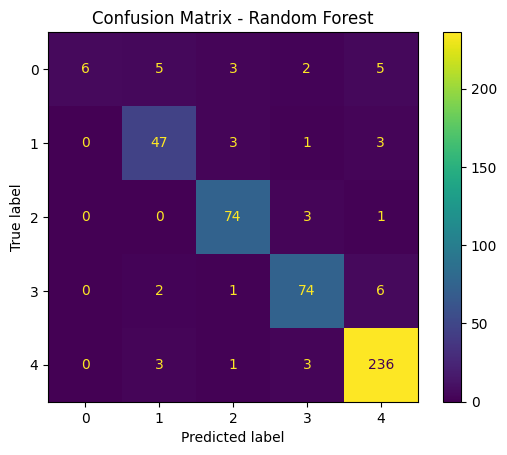

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm_rf = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp.plot()

plt.title("Confusion Matrix - Random Forest")
plt.show()